# TASK-007: AUTO-07p validation for reduced Berton 3D model

This notebook records the reproducible AUTO commands and Python cross-checks used for TASK-007. It runs the AUTO problem in `auto/berton_reduced_3d`, parses the saved `b.*` branch files, and plots the Routh-Hurwitz residuals inspected for stability/Hopf agreement.

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
if REPO.name == 'notebooks':
    REPO = REPO.parent
SCRIPTS = REPO / 'scripts'
if str(SCRIPTS) not in sys.path:
    sys.path.append(str(SCRIPTS))

from berton_3d_auto_task007_validate import AUTO_DIR, parse_auto_branch, validate

AUTO_CMD = REPO / 'auto' / 'berton_reduced_3d' / 'run_auto.sh'
AUTO_OUTPUTS = [
    AUTO_DIR / 'b.bert3d-k', AUTO_DIR / 's.bert3d-k', AUTO_DIR / 'd.bert3d-k',
    AUTO_DIR / 'b.bert3d-alpha', AUTO_DIR / 's.bert3d-alpha', AUTO_DIR / 'd.bert3d-alpha',
]
AUTO_CMD, AUTO_OUTPUTS

(PosixPath('/home/iross/research/ongoing/ai-class/code/cloud-rom/auto/berton_reduced_3d/run_auto.sh'),
 [PosixPath('/home/iross/research/ongoing/ai-class/code/cloud-rom/auto/berton_reduced_3d/b.bert3d-k'),
  PosixPath('/home/iross/research/ongoing/ai-class/code/cloud-rom/auto/berton_reduced_3d/s.bert3d-k'),
  PosixPath('/home/iross/research/ongoing/ai-class/code/cloud-rom/auto/berton_reduced_3d/d.bert3d-k'),
  PosixPath('/home/iross/research/ongoing/ai-class/code/cloud-rom/auto/berton_reduced_3d/b.bert3d-alpha'),
  PosixPath('/home/iross/research/ongoing/ai-class/code/cloud-rom/auto/berton_reduced_3d/s.bert3d-alpha'),
  PosixPath('/home/iross/research/ongoing/ai-class/code/cloud-rom/auto/berton_reduced_3d/d.bert3d-alpha')])

## Run AUTO

The exact command used from the repository root is:

```bash
bash auto/berton_reduced_3d/run_auto.sh
```

This writes `b/s/d.bert3d-k` and `b/s/d.bert3d-alpha`.

In [2]:
# Uncomment to regenerate AUTO outputs from the notebook.
# subprocess.run(['bash', str(AUTO_CMD)], cwd=REPO, check=True)
[path.relative_to(REPO) for path in AUTO_OUTPUTS if path.exists()]

[PosixPath('auto/berton_reduced_3d/b.bert3d-k'),
 PosixPath('auto/berton_reduced_3d/s.bert3d-k'),
 PosixPath('auto/berton_reduced_3d/d.bert3d-k'),
 PosixPath('auto/berton_reduced_3d/b.bert3d-alpha'),
 PosixPath('auto/berton_reduced_3d/s.bert3d-alpha'),
 PosixPath('auto/berton_reduced_3d/d.bert3d-alpha')]

## Cross-check AUTO output against the corrected cubic

The validation script recomputes the corrected cubic at each parsed AUTO branch point, checks `a0`, checks `a2*a1-a0`, confirms drag-rate stability, and confirms AUTO's `HB` label on the `alpha_grad` branch.

In [3]:
validate(run_auto_first=False)


Derive baseline fixed-point derivatives from the existing Berton model
Provenance and values:
- Atmosphere: atmosphere_for_case(0, oscillatory=True); Case 0 eta_a(z), H_a3=0.61, W_a0=0.6 m/s.
- r*: D_i/2 with D_i=131 um, the paper's limiting mass-equivalent diameter.
- z*: solved local reduced growth balance s(z*) = R(z*, r*) using existing LocalDiagnostics.
- beta: force balance W_a(z*) = beta*r*^2, not an independent fit.
- G: converted from existing mass-growth law to dr/dt = (G/r)*(S_i-1-R).
- w_prime: -dW_a/dz from existing updraft profile; it is zero because z* is above the updraft ramp.
- sigma_S: -d(S_i-1)/dz from existing saturation thermodynamics.
- R_r: R/r from the reduced linear-in-r radiative form.
- R_zeta: finite difference of existing radiative_correction at fixed crystal geometry.
z*                         = 9618.062976835217 m
r*                         = 6.550000000000e-05 m
eta_a(z*)                  = 1.023612595367e+00
S_i(z*) - 1                = 2.20733458073

## Plot inspected AUTO diagnostics

The alpha branch crosses zero Routh-Hurwitz residual at the AUTO Hopf point; the k branch stays positive over the saved continuation.

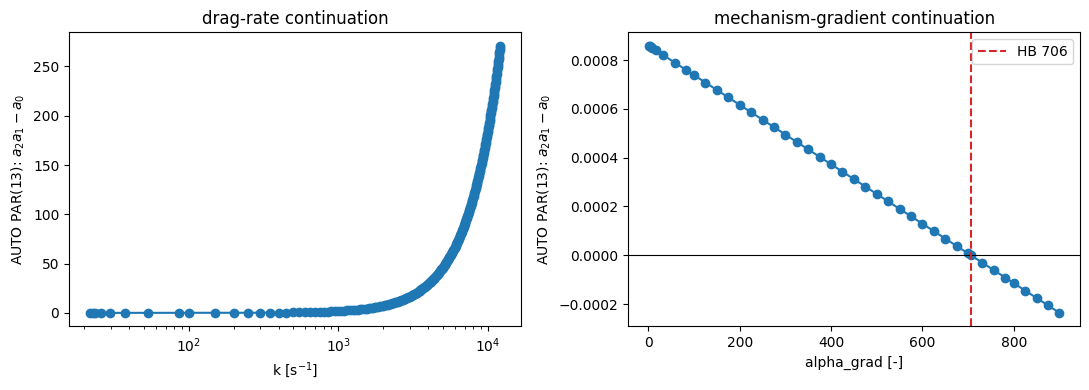

In [4]:
k_rows = parse_auto_branch(AUTO_DIR / 'b.bert3d-k', 'k')
alpha_rows = parse_auto_branch(AUTO_DIR / 'b.bert3d-alpha', 'alpha_grad')
hb_rows = [row for row in alpha_rows if abs(row.ty) == 3]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([row.active_value for row in k_rows], [row.rh_residual for row in k_rows], marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('k [s$^{-1}$]')
axes[0].set_ylabel('AUTO PAR(13): $a_2 a_1 - a_0$')
axes[0].set_title('drag-rate continuation')

axes[1].plot([row.active_value for row in alpha_rows], [row.rh_residual for row in alpha_rows], marker='o')
axes[1].axhline(0.0, color='black', linewidth=0.8)
for row in hb_rows:
    axes[1].axvline(row.active_value, color='tab:red', linestyle='--', label=f'HB {row.active_value:.3g}')
axes[1].set_xlabel('alpha_grad [-]')
axes[1].set_ylabel('AUTO PAR(13): $a_2 a_1 - a_0$')
axes[1].set_title('mechanism-gradient continuation')
axes[1].legend()
fig.tight_layout()